In [17]:
# Kaggle bootstrap: map dataset paths to this notebook's expected local layout.
import os
import glob
import shutil
from collections import Counter


def _find_icbhi_root_under_kaggle_input():
    # Preferred: explicit ICBHI_final_database folder.
    candidates = sorted(glob.glob('/kaggle/input/**/ICBHI_final_database', recursive=True))
    for path in candidates:
        if os.path.isdir(path) and len(glob.glob(os.path.join(path, '*.wav'))) > 0:
            return path

    # Fallback: infer root from diagnosis location.
    diag_paths = sorted(glob.glob('/kaggle/input/**/ICBHI_Challenge_diagnosis.txt', recursive=True))
    for diag in diag_paths:
        root = os.path.dirname(os.path.dirname(diag))
        if os.path.isdir(root) and len(glob.glob(os.path.join(root, '*.wav'))) > 0:
            return root

    # Last resort: pick directory containing the most wav files.
    wav_paths = glob.glob('/kaggle/input/**/*.wav', recursive=True)
    if len(wav_paths) == 0:
        return None

    counts = Counter(os.path.dirname(w) for w in wav_paths)
    return counts.most_common(1)[0][0]


def _create_symlink_or_copytree(src_dir, dst_dir):
    if os.path.exists(dst_dir):
        return 'exists'

    parent = os.path.dirname(os.path.abspath(dst_dir))
    if parent:
        os.makedirs(parent, exist_ok=True)

    try:
        os.symlink(src_dir, dst_dir, target_is_directory=True)
        return 'symlink'
    except Exception:
        shutil.copytree(src_dir, dst_dir)
        return 'copied'


IN_KAGGLE = os.path.exists('/kaggle/input')
if IN_KAGGLE:
    os.environ.setdefault('HF_HOME', '/kaggle/working/hf_home')
    os.environ.setdefault('TRANSFORMERS_CACHE', '/kaggle/working/hf_home')
    os.makedirs(os.environ['HF_HOME'], exist_ok=True)

    source_root = _find_icbhi_root_under_kaggle_input()
    if source_root is None:
        raise FileNotFoundError('Could not find ICBHI data under /kaggle/input. Attach the dataset first.')

    local_root = os.path.abspath('ICBHI_final_database')
    link_mode = _create_symlink_or_copytree(source_root, local_root)

    diagnosis_target = os.path.join(local_root, 'important', 'ICBHI_Challenge_diagnosis.txt')
    if not os.path.exists(diagnosis_target):
        diagnosis_matches = sorted(glob.glob('/kaggle/input/**/ICBHI_Challenge_diagnosis.txt', recursive=True))
        if len(diagnosis_matches) == 0:
            raise FileNotFoundError('Could not find ICBHI_Challenge_diagnosis.txt under /kaggle/input.')
        os.makedirs(os.path.dirname(diagnosis_target), exist_ok=True)
        shutil.copy2(diagnosis_matches[0], diagnosis_target)

    print('Kaggle bootstrap ready.')
    print('Source dataset root:', source_root)
    print('Local dataset root :', local_root, f'({link_mode})')
    print('Diagnosis file     :', diagnosis_target)
else:
    print('Kaggle bootstrap skipped (not running on Kaggle).')

%pip install -q librosa soundfile transformers torch-geometric  matplotlib seaborn

Kaggle bootstrap skipped (not running on Kaggle).
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\NASSSCAT\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [1]:
# ============================================
# CELL 2: Robust Dataset + Metadata Setup
# ============================================

import os
import glob
import pandas as pd

IN_KAGGLE = os.path.exists('/kaggle/input')


def resolve_audio_folder(path_hint):
    candidates = []

    if path_hint:
        candidates.append(path_hint)

    if IN_KAGGLE:
        candidates.extend([
            '/kaggle/input/datasets/catherinenassali/icbhi-final-database/ICBHI_final_database',
            '/kaggle/input/datasets/catherinenassali/icbhi-final-database',
        ])
        candidates.extend(sorted(glob.glob('/kaggle/input/**/ICBHI_final_database', recursive=True)))

    for cand in candidates:
        if os.path.isdir(cand):
            if len(glob.glob(os.path.join(cand, '*.wav'))) > 0:
                return cand
            subdirs = [d for d in glob.glob(os.path.join(cand, '*')) if os.path.isdir(d)]
            for s in subdirs:
                if len(glob.glob(os.path.join(s, '*.wav'))) > 0:
                    return s

    raise FileNotFoundError('Could not resolve an audio folder containing .wav files.')


def resolve_diagnosis_file(path_hint):
    candidates = []

    if path_hint:
        candidates.append(path_hint)

    if path_hint and os.path.isdir(path_hint):
        candidates.extend([
            os.path.join(path_hint, 'ICBHI_Challenge_diagnosis.txt'),
            os.path.join(path_hint, 'important', 'ICBHI_Challenge_diagnosis.txt'),
        ])
        candidates.extend(sorted(glob.glob(os.path.join(path_hint, '**', 'ICBHI_Challenge_diagnosis.txt'), recursive=True)))

    candidates.extend([
        'ICBHI_final_database/important/ICBHI_Challenge_diagnosis.txt',
        'ICBHI_Challenge_diagnosis.txt',
    ])

    if IN_KAGGLE:
        candidates.extend(sorted(glob.glob('/kaggle/input/**/ICBHI_Challenge_diagnosis.txt', recursive=True)))

    for cand in candidates:
        if os.path.isfile(cand):
            return cand

    raise FileNotFoundError('Could not resolve ICBHI_Challenge_diagnosis.txt from provided path hint.')


if IN_KAGGLE:
    audio_folder_hint = '/kaggle/input/datasets/catherinenassali/icbhi-final-database/ICBHI_final_database'
    diagnosis_file_hint = '/kaggle/input/datasets/catherinenassali/important'
else:
    audio_folder_hint = 'ICBHI_final_database'
    diagnosis_file_hint = 'ICBHI_final_database/important/ICBHI_Challenge_diagnosis.txt'

audio_folder_path = resolve_audio_folder(audio_folder_hint)
diagnosis_file_path = resolve_diagnosis_file(diagnosis_file_hint)

print('Audio folder path:', audio_folder_path)
print('Audio folder exists:', os.path.exists(audio_folder_path))
print('Diagnosis file path:', diagnosis_file_path)
print('Diagnosis file exists:', os.path.exists(diagnosis_file_path))


def load_diagnosis_file(path):
    if os.path.isdir(path):
        raise IsADirectoryError('Diagnosis path is a directory. Expected .txt file: ' + str(path))
    if not os.path.isfile(path):
        raise FileNotFoundError('Diagnosis file not found: ' + str(path))

    df = pd.read_csv(path, sep='\t', header=None, names=['patient_id', 'diagnosis'])
    df['patient_id'] = df['patient_id'].astype(str)
    return df


def scan_dataset(audio_folder):
    wav_files = sorted(glob.glob(os.path.join(audio_folder, '*.wav')))
    ann_files = sorted(glob.glob(os.path.join(audio_folder, '*.txt')))

    wav_map = {os.path.splitext(os.path.basename(f))[0]: f for f in wav_files}
    ann_map = {os.path.splitext(os.path.basename(f))[0]: f for f in ann_files}

    paired = []
    missing_ann = 0
    for base, wav_path in wav_map.items():
        if base in ann_map:
            paired.append((base, wav_path, ann_map[base]))
        else:
            missing_ann += 1

    return paired, missing_ann, len(wav_files)


def extract_patient_id(base_filename):
    return base_filename.split('_')[0]


def build_metadata_table(paired_files, diagnosis_df):
    rows = []
    diag_map = dict(zip(diagnosis_df['patient_id'], diagnosis_df['diagnosis']))

    for base, wav_path, ann_path in paired_files:
        patient_id = extract_patient_id(base)
        diagnosis = diag_map.get(patient_id, 'Unknown')
        rows.append({
            'file_id': base,
            'patient_id': patient_id,
            'diagnosis': diagnosis,
            'wav_path': wav_path,
            'ann_path': ann_path,
        })

    return pd.DataFrame(rows)


diagnosis_df = load_diagnosis_file(diagnosis_file_path)
paired_files, missing_ann, total_wavs = scan_dataset(audio_folder_path)
meta_df = build_metadata_table(paired_files, diagnosis_df)

print('\n=== Dataset Summary ===')
print('Diagnosis table shape:', diagnosis_df.shape)
print('Total wav files:', total_wavs)
print('Paired wav+annotation:', len(paired_files))
print('Missing annotation files:', missing_ann)
print('Metadata shape:', meta_df.shape)
print('\nExample pair:')
print(paired_files[0] if len(paired_files) else 'No pairs found')
print('\nDiagnosis distribution:')
print(meta_df['diagnosis'].value_counts())

Audio folder path: ICBHI_final_database
Audio folder exists: True
Diagnosis file path: ICBHI_final_database/important/ICBHI_Challenge_diagnosis.txt
Diagnosis file exists: True

=== Dataset Summary ===
Diagnosis table shape: (126, 2)
Total wav files: 920
Paired wav+annotation: 920
Missing annotation files: 0
Metadata shape: (920, 5)

Example pair:
('101_1b1_Al_sc_Meditron', 'ICBHI_final_database\\101_1b1_Al_sc_Meditron.wav', 'ICBHI_final_database\\101_1b1_Al_sc_Meditron.txt')

Diagnosis distribution:
diagnosis
COPD              793
Pneumonia          37
Healthy            35
URTI               23
Bronchiectasis     16
Bronchiolitis      13
LRTI                2
Asthma              1
Name: count, dtype: int64


Patched Wav2Vec2FeatureCache.compute_and_cache_file for CPU fallback.
Inserted safe wav2vec wrapper (CPU fallback).


Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base-960h
Key               | Status     | 
------------------+------------+-
lm_head.weight    | UNEXPECTED | 
lm_head.bias      | UNEXPECTED | 
masked_spec_embed | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


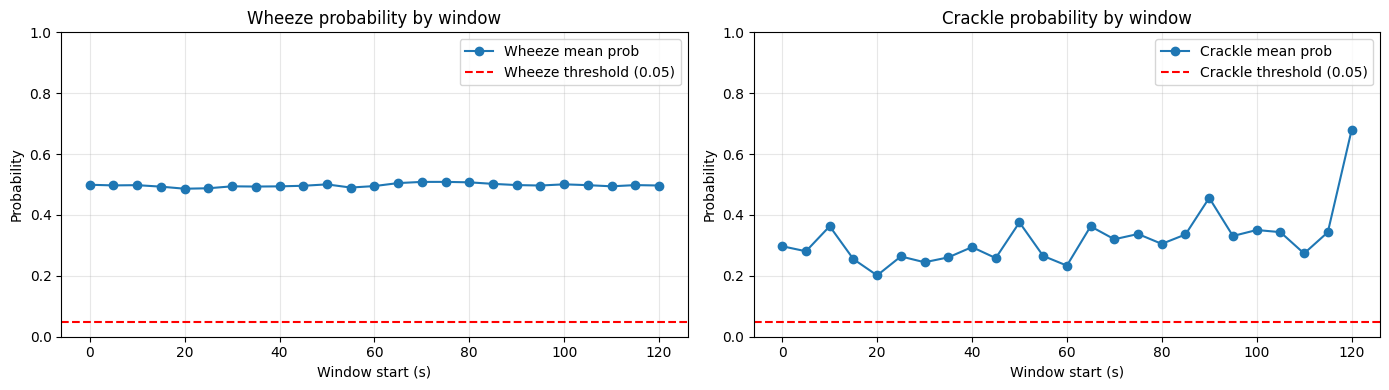


=== Trained GraphSAGE MP3 Test Completed ===
Checkpoint: output files\saved models\best_respiratory_graphsage_temp_scaled.pth
Audio: E:\studies\FINAL YR PROJECT\model\model_comparisons\audio_test_files\sounds-of-asthma-wheezing-lung-sounds.mp3
Audio duration (s): 120.001
Windows: 25 | Frames: 250
Thresholds -> wheeze=0.05, crackle=0.05
Temperature -> wheeze=10.0000, crackle=0.5000
Saved: output files\sample_runs\graphsage_mp3_window_report.csv
Saved: output files\sample_runs\graphsage_mp3_frame_report.csv
Saved: output files\sample_runs\graphsage_mp3_summary.json
Saved: output files\sample_runs\graphsage_mp3_window_probs.png

First 10 windows:
 start_sec  end_sec  num_frames  wheeze_prob_mean  wheeze_prob_max  crackle_prob_mean  crackle_prob_max  wheeze_pos_frames  crackle_pos_frames  wheeze_window_pred  crackle_window_pred
       0.0      5.0          10          0.499205         0.504368           0.297283          0.365111                 10                  10                   1 

In [ ]:
# Kaggle GPU-compat patch: safe wav2vec CPU-fallback and safe cache compute
# Inserts CPU-fallback wrappers so wav2vec inference won't crash on incompatible CUDA kernels.
import os
import json
import pickle
from pathlib import Path

import librosa
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv
from transformers import Wav2Vec2Model, Wav2Vec2Processor


def _safe_model_forward(model, input_values):
    try:
        with torch.no_grad():
            return model(input_values)
    except Exception as e:
        print("Wav2Vec forward on device failed, falling back to CPU:", repr(e))
        model_cpu = model.to("cpu")
        out = model_cpu(input_values.cpu())
        try:
            model.to(torch.device("cuda"))
        except Exception:
            pass
        return out


def wav2vec_frame_embedding_safe(frame_audio, sr=16000):
    proc = globals().get("processor", None)
    model = globals().get("wav2vec_model", None)
    if proc is None or model is None:
        proc = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base-960h")
        model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base-960h")

    inputs = proc(frame_audio, sampling_rate=sr, return_tensors="pt", padding=True)
    input_values = inputs.input_values

    try:
        model_device = next(model.parameters()).device
    except StopIteration:
        model_device = torch.device("cpu")

    if model_device.type == "cuda" and torch.cuda.is_available():
        input_values = input_values.to(model_device)
    else:
        input_values = input_values.cpu()

    out = _safe_model_forward(model, input_values)
    hidden_states = out.last_hidden_state
    emb = hidden_states.mean(dim=1).squeeze(0)
    return emb.cpu().numpy().astype("float32")


# Monkeypatch Wav2Vec2FeatureCache.compute_and_cache_file for CPU fallback (if class exists)
if "Wav2Vec2FeatureCache" in globals():

    def _safe_compute_and_cache_file(self, audio_path, batch_size=32):
        cache_path = self._cache_key(audio_path)
        if os.path.exists(cache_path):
            with open(cache_path, "rb") as f:
                return pickle.load(f)

        y, _ = librosa.load(audio_path, sr=self.sr, mono=True)
        num_frames = len(y) // self.frame_samples
        frames = [
            y[i * self.frame_samples : (i + 1) * self.frame_samples]
            for i in range(num_frames)
        ]

        embeddings = []
        try:
            with torch.no_grad():
                for i in range(0, len(frames), batch_size):
                    batch = frames[i : i + batch_size]
                    inputs = self.processor(
                        batch,
                        sampling_rate=self.sr,
                        return_tensors="pt",
                        padding=True,
                    )
                    input_values = inputs.input_values.to(self._device)
                    out = self.model(input_values)
                    emb = out.last_hidden_state.mean(dim=1).cpu().numpy()
                    embeddings.append(emb)
        except Exception as e:
            print(
                "Wav2Vec2 cache compute failed on device; falling back to CPU:",
                repr(e),
            )
            model_cpu = self.model.to("cpu")
            for i in range(0, len(frames), batch_size):
                batch = frames[i : i + batch_size]
                inputs = self.processor(
                    batch,
                    sampling_rate=self.sr,
                    return_tensors="pt",
                    padding=True,
                )
                input_values = inputs.input_values.cpu()
                out = model_cpu(input_values)
                emb = out.last_hidden_state.mean(dim=1).cpu().numpy()
                embeddings.append(emb)
            try:
                self.model.to(self._device)
            except Exception:
                pass

        embeddings = (
            np.concatenate(embeddings, axis=0)
            if len(embeddings)
            else np.zeros((0, 768), dtype=np.float32)
        )
        data = {
            "embeddings": embeddings.astype(np.float32),
            "audio_duration": len(y) / self.sr,
            "num_frames": num_frames,
        }
        with open(cache_path, "wb") as f:
            pickle.dump(data, f, protocol=pickle.HIGHEST_PROTOCOL)
        return data

    Wav2Vec2FeatureCache.compute_and_cache_file = _safe_compute_and_cache_file
    print("Patched Wav2Vec2FeatureCache.compute_and_cache_file for CPU fallback.")


# Override global wav2vec_frame_embedding used elsewhere
globals()["wav2vec_frame_embedding"] = wav2vec_frame_embedding_safe
print("Inserted safe wav2vec wrapper (CPU fallback).")



In [2]:
"""# MODEL TRAINING (GraphSAGE FROM SCRATCH + TEMPERATURE SCALING)"""

# ============================================================
# GraphSAGE training plan in this cell:
# 1) Patient-wise split
# 2) Build wav2vec cache + graph datasets
# 3) Train GraphSAGE from scratch with curriculum regularization
#    - increasing mixup strength by epoch
#    - increasing feature cutout by epoch
#    - dropout + batch norm + weight decay
# 4) Fit temperature scaling on validation logits
# 5) Re-tune thresholds on calibrated validation probabilities
# 6) Evaluate calibrated performance on test split
# ============================================================

import os
import json
import random
import hashlib
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import librosa

try:
    import matplotlib.pyplot as plt
    HAS_MATPLOTLIB = True
except Exception:
    plt = None
    HAS_MATPLOTLIB = False
    print("matplotlib is not available. Training curves will be skipped.")

from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_auc_score, average_precision_score

from torch.utils.data import Dataset
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import SAGEConv


def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(42)


# Keep training on CUDA when available, but force wav2vec cache to CPU by default.
# This avoids Kaggle "no kernel image" runtime crashes on unsupported GPU kernels.
FORCE_WAV2VEC_CPU = True
TRAIN_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
WAV2VEC_DEVICE = torch.device("cpu") if FORCE_WAV2VEC_CPU else TRAIN_DEVICE

print("Training device:", TRAIN_DEVICE)
print("Wav2Vec cache device:", WAV2VEC_DEVICE)


# ============================================================
# 1. WAV2VEC2 CACHE
# ============================================================

class Wav2Vec2FeatureCache:
    def __init__(
        self,
        cache_dir="./cache/wav2vec2_embeddings",
        sr=16000,
        frame_seconds=0.5,
        model_name="facebook/wav2vec2-base-960h",
        device=WAV2VEC_DEVICE,
        batch_size_cache=24,
    ):
        self.cache_dir = cache_dir
        self.sr = int(sr)
        self.frame_seconds = float(frame_seconds)
        self.frame_samples = int(self.sr * self.frame_seconds)
        self.model_name = model_name
        self.device = torch.device(device)
        self.batch_size_cache = int(batch_size_cache)

        os.makedirs(self.cache_dir, exist_ok=True)

        self._processor = None
        self._model = None

    @property
    def processor(self):
        if self._processor is None:
            from transformers import Wav2Vec2Processor
            self._processor = Wav2Vec2Processor.from_pretrained(self.model_name)
        return self._processor

    @property
    def model(self):
        if self._model is None:
            from transformers import Wav2Vec2Model
            self._model = Wav2Vec2Model.from_pretrained(self.model_name).to(self.device)
            self._model.eval()
            for p in self._model.parameters():
                p.requires_grad = False
        return self._model

    def _cache_key(self, audio_path):
        mtime = os.path.getmtime(audio_path)
        file_hash = hashlib.md5(f"{audio_path}_{mtime}_{self.frame_seconds}".encode()).hexdigest()
        return os.path.join(self.cache_dir, f"{file_hash}.pkl")

    def _safe_forward(self, input_values):
        try:
            with torch.no_grad():
                out = self.model(input_values.to(self.device))
            return out
        except Exception as e:
            print("Wav2Vec forward failed on", self.device, "-> fallback to CPU:", repr(e))
            with torch.no_grad():
                model_cpu = self.model.to("cpu")
                out = model_cpu(input_values.cpu())
            try:
                self.model.to(self.device)
            except Exception:
                pass
            return out

    def compute_and_cache_file(self, audio_path):
        cache_path = self._cache_key(audio_path)
        if os.path.exists(cache_path):
            with open(cache_path, "rb") as f:
                return pickle.load(f)

        y, _ = librosa.load(audio_path, sr=self.sr, mono=True)

        num_frames = len(y) // self.frame_samples
        frames = []
        for i in range(num_frames):
            s = i * self.frame_samples
            e = s + self.frame_samples
            frames.append(y[s:e])

        embeddings = []
        if len(frames) > 0:
            for i in range(0, len(frames), self.batch_size_cache):
                batch = frames[i:i + self.batch_size_cache]
                inputs = self.processor(batch, sampling_rate=self.sr, return_tensors="pt", padding=True)
                out = self._safe_forward(inputs.input_values)
                emb = out.last_hidden_state.mean(dim=1).cpu().numpy()
                embeddings.append(emb)

        emb_arr = np.concatenate(embeddings, axis=0) if len(embeddings) else np.zeros((0, 768), dtype=np.float32)

        payload = {
            "embeddings": emb_arr.astype(np.float32),
            "audio_duration": len(y) / self.sr,
            "num_frames": int(num_frames),
        }

        with open(cache_path, "wb") as f:
            pickle.dump(payload, f, protocol=pickle.HIGHEST_PROTOCOL)

        return payload

    def get_chunk_embeddings(self, audio_path, start_sec, chunk_seconds=5.0):
        cache = self.compute_and_cache_file(audio_path)

        start_frame = int(start_sec / self.frame_seconds)
        frames_per_chunk = int(chunk_seconds / self.frame_seconds)
        end_frame = min(start_frame + frames_per_chunk, cache["embeddings"].shape[0])

        if start_frame >= cache["embeddings"].shape[0]:
            return np.zeros((frames_per_chunk, 768), dtype=np.float32)

        emb = cache["embeddings"][start_frame:end_frame]
        if emb.shape[0] < frames_per_chunk:
            pad = np.zeros((frames_per_chunk - emb.shape[0], 768), dtype=np.float32)
            emb = np.concatenate([emb, pad], axis=0)

        return emb.astype(np.float32)


# ============================================================
# 2. GRAPH BUILDING
# ============================================================

def build_temporal_edges(num_nodes, max_hop=2):
    edges = []
    max_hop = max(1, int(max_hop))
    for hop in range(1, max_hop + 1):
        for i in range(max(0, int(num_nodes) - hop)):
            j = i + hop
            edges.append([i, j])
            edges.append([j, i])
    return edges


def build_similarity_edges(x_np, k=4, temporal_hops=0):
    x = torch.tensor(x_np, dtype=torch.float32)
    x = F.normalize(x, dim=1)

    sim = x @ x.T
    n = sim.shape[0]

    edges = []
    for i in range(n):
        _, idx = torch.topk(sim[i], k=min(k + 1, n))
        for j in idx.tolist():
            if i != j:
                edges.append([i, j])
                edges.append([j, i])

    if int(temporal_hops) > 0:
        edges.extend(build_temporal_edges(n, max_hop=int(temporal_hops)))

    if len(edges) == 0:
        return torch.empty((2, 0), dtype=torch.long)

    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    return torch.unique(edge_index, dim=1)


# ============================================================
# 3. DATASET
# ============================================================

class RespiratoryGraphDataset(Dataset):
    def __init__(
        self,
        meta_df,
        cache_dir="./cache/wav2vec2_embeddings",
        chunk_seconds=5.0,
        frame_seconds=0.5,
        k_edges=4,
        crackle_focus_enabled=False,
        crackle_focus_prob=0.65,
        crackle_focus_jitter_sec=1.2,
        samples_per_file=8,
        temporal_hops=2,
        pre_cache=False,
    ):
        self.meta_df = meta_df.reset_index(drop=True).copy()
        self.chunk_seconds = float(chunk_seconds)
        self.frame_seconds = float(frame_seconds)
        self.frames_per_chunk = int(self.chunk_seconds / self.frame_seconds)
        self.k_edges = int(k_edges)
        self.temporal_hops = int(temporal_hops)
        self.samples_per_file = int(samples_per_file)

        self.crackle_focus_enabled = bool(crackle_focus_enabled)
        self.crackle_focus_prob = float(np.clip(crackle_focus_prob, 0.0, 1.0))
        self.crackle_focus_jitter_sec = max(0.0, float(crackle_focus_jitter_sec))

        self.cache = Wav2Vec2FeatureCache(
            cache_dir=cache_dir,
            sr=16000,
            frame_seconds=self.frame_seconds,
            device=WAV2VEC_DEVICE,
        )

        if "file_id" not in self.meta_df.columns:
            self.meta_df["file_id"] = self.meta_df["wav_path"].map(lambda p: os.path.splitext(os.path.basename(p))[0])

        self.annotations = {}
        self.crackle_segments = {}

        for _, row in self.meta_df.iterrows():
            ann = pd.read_csv(
                row["ann_path"],
                sep="\t",
                header=None,
                names=["start", "end", "crackle", "wheeze"],
            )
            wav_path = row["wav_path"]
            self.annotations[wav_path] = ann

            crackle_rows = ann[(ann["crackle"] == 1) & (ann["end"] > ann["start"])]
            self.crackle_segments[wav_path] = [
                (float(r["start"]), float(r["end"])) for _, r in crackle_rows.iterrows()
            ]

        self.unique_files = self.meta_df["wav_path"].unique().tolist()

        if pre_cache:
            print(f"Pre-caching {len(self.unique_files)} files...")
            for p in tqdm(self.unique_files):
                self.cache.compute_and_cache_file(p)

    def __len__(self):
        return len(self.meta_df) * self.samples_per_file

    def _labels_for_chunk(self, ann_df, chunk_start):
        crackle = np.zeros(self.frames_per_chunk, dtype=np.float32)
        wheeze = np.zeros(self.frames_per_chunk, dtype=np.float32)

        for i in range(self.frames_per_chunk):
            fs = chunk_start + i * self.frame_seconds
            fe = fs + self.frame_seconds

            overlaps = ann_df[(ann_df["start"] < fe) & (ann_df["end"] > fs)]
            for _, row in overlaps.iterrows():
                overlap_start = max(fs, row["start"])
                overlap_end = min(fe, row["end"])
                overlap_len = max(0.0, overlap_end - overlap_start)
                if overlap_len / self.frame_seconds >= 0.3:
                    if int(row["crackle"]) == 1:
                        crackle[i] = 1.0
                    if int(row["wheeze"]) == 1:
                        wheeze[i] = 1.0

        return crackle, wheeze

    def _sample_chunk_start(self, wav_path, max_start):
        if max_start <= 0:
            return 0.0, "full_audio"

        if not self.crackle_focus_enabled:
            return float(np.random.uniform(0.0, max_start)), "uniform"

        if np.random.rand() > self.crackle_focus_prob:
            return float(np.random.uniform(0.0, max_start)), "uniform_mix"

        segs = self.crackle_segments.get(wav_path, [])
        if len(segs) == 0:
            return float(np.random.uniform(0.0, max_start)), "uniform_no_crackle"

        s, e = segs[np.random.randint(0, len(segs))]
        center = 0.5 * (s + e)
        jitter = np.random.uniform(-self.crackle_focus_jitter_sec, self.crackle_focus_jitter_sec)
        focused = center - 0.5 * self.chunk_seconds + jitter
        focused = float(np.clip(focused, 0.0, max_start))
        return focused, "crackle_focus"

    def __getitem__(self, idx):
        row = self.meta_df.sample(1).iloc[0]
        wav_path = row["wav_path"]

        cache_data = self.cache.compute_and_cache_file(wav_path)
        max_start = max(0.0, cache_data["audio_duration"] - self.chunk_seconds)
        start_sec, sample_mode = self._sample_chunk_start(wav_path, max_start)

        x_np = self.cache.get_chunk_embeddings(wav_path, start_sec, self.chunk_seconds)
        edge_index = build_similarity_edges(x_np, k=self.k_edges, temporal_hops=self.temporal_hops)

        ann_df = self.annotations[wav_path]
        c_lbl, w_lbl = self._labels_for_chunk(ann_df, start_sec)

        data = Data(
            x=torch.tensor(x_np, dtype=torch.float32),
            edge_index=edge_index,
            y_wheeze=torch.tensor(w_lbl, dtype=torch.float32),
            y_crackle=torch.tensor(c_lbl, dtype=torch.float32),
        )
        data.sample_mode = sample_mode
        data.file_id = row["file_id"]
        data.patient_id = row["patient_id"]
        return data


# ============================================================
# 4. MODEL + CURRICULUM AUGMENTATIONS
# ============================================================

class RespiratoryGraphSAGE(nn.Module):
    def __init__(self, input_dim=768, hidden_dim=256, num_layers=3, dropout=0.5):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, hidden_dim)

        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        for _ in range(num_layers):
            self.convs.append(SAGEConv(hidden_dim, hidden_dim))
            self.norms.append(nn.BatchNorm1d(hidden_dim))

        self.dropout = float(dropout)

        self.wheeze_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(self.dropout),
            nn.Linear(hidden_dim // 2, 1),
        )

        self.crackle_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(self.dropout),
            nn.Linear(hidden_dim // 2, 1),
        )

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.input_proj(x)

        for conv, norm in zip(self.convs, self.norms):
            x_new = conv(x, edge_index)
            x_new = F.relu(x_new)
            x_new = norm(x_new)
            x = x + x_new
            x = F.dropout(x, p=self.dropout, training=self.training)

        w_logits = self.wheeze_head(x).squeeze(-1)
        c_logits = self.crackle_head(x).squeeze(-1)
        return w_logits, c_logits


def apply_feature_cutout(x, drop_prob=0.0):
    if drop_prob <= 0.0:
        return x
    mask = torch.rand_like(x) < float(drop_prob)
    return x.masked_fill(mask, 0.0)


def apply_node_mixup(x, y_w, y_c, alpha=0.0):
    if alpha <= 1e-8:
        return x, y_w, y_c, 1.0

    lam = float(np.random.beta(alpha, alpha))
    idx = torch.randperm(x.shape[0], device=x.device)

    x_mix = lam * x + (1.0 - lam) * x[idx]
    y_w_mix = lam * y_w + (1.0 - lam) * y_w[idx]
    y_c_mix = lam * y_c + (1.0 - lam) * y_c[idx]

    return x_mix, y_w_mix, y_c_mix, lam


# ============================================================
# 5. METRICS
# ============================================================

def sigmoid_np(x):
    return 1.0 / (1.0 + np.exp(-np.asarray(x, dtype=np.float32)))


def safe_auroc(y_true, y_prob):
    y_true = np.asarray(y_true).astype(int)
    if len(np.unique(y_true)) < 2:
        return None
    return float(roc_auc_score(y_true, y_prob))


def safe_auprc(y_true, y_prob):
    y_true = np.asarray(y_true).astype(int)
    if len(np.unique(y_true)) < 2:
        return None
    return float(average_precision_score(y_true, y_prob))


def binary_stats(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=np.float32)
    y_pred = (y_prob >= float(threshold)).astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    eps = 1e-9
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    specificity = tn / (tn + fp + eps)
    f1 = 2.0 * precision * recall / (precision + recall + eps)
    bal_acc = 0.5 * (recall + specificity)

    return {
        "tp": int(tp),
        "fp": int(fp),
        "tn": int(tn),
        "fn": int(fn),
        "precision": float(precision),
        "recall": float(recall),
        "specificity": float(specificity),
        "f1": float(f1),
        "balanced_accuracy": float(bal_acc),
        "roc_auc": safe_auroc(y_true, y_prob),
        "pr_auc": safe_auprc(y_true, y_prob),
    }


def best_threshold_by_f1(y_true, y_prob, t_min=0.05, t_max=0.95, t_step=0.01):
    best_t = 0.5
    best_f1 = -1.0
    for t in np.arange(t_min, t_max + 1e-9, t_step):
        f1 = binary_stats(y_true, y_prob, threshold=float(t))["f1"]
        if f1 > best_f1:
            best_f1 = f1
            best_t = float(t)
    return best_t, float(best_f1)


@torch.no_grad()
def collect_logits_targets(model, loader, device):
    model.eval()

    w_logits_all, c_logits_all = [], []
    w_true_all, c_true_all = [], []
    chunk_ids_all = []

    chunk_offset = 0

    for batch in loader:
        batch = batch.to(device)
        w_logits, c_logits = model(batch)

        w_logits_all.append(w_logits.detach().cpu().numpy())
        c_logits_all.append(c_logits.detach().cpu().numpy())
        w_true_all.append(batch.y_wheeze.detach().cpu().numpy())
        c_true_all.append(batch.y_crackle.detach().cpu().numpy())

        local_chunk_ids = batch.batch.detach().cpu().numpy()
        uniq = np.unique(local_chunk_ids)
        remap = {u: chunk_offset + i for i, u in enumerate(uniq.tolist())}
        remapped = np.array([remap[u] for u in local_chunk_ids], dtype=np.int64)
        chunk_ids_all.append(remapped)
        chunk_offset += len(uniq)

    return (
        np.concatenate(w_logits_all).astype(np.float32),
        np.concatenate(c_logits_all).astype(np.float32),
        np.concatenate(w_true_all).astype(np.float32),
        np.concatenate(c_true_all).astype(np.float32),
        np.concatenate(chunk_ids_all).astype(np.int64),
    )


def chunk_level_eval(prob, true, chunk_ids, threshold, min_positive_frames=2):
    prob = np.asarray(prob, dtype=np.float32)
    true = np.asarray(true, dtype=np.float32)
    chunk_ids = np.asarray(chunk_ids)

    chunk_true = []
    chunk_pred = []

    for cid in np.unique(chunk_ids):
        m = chunk_ids == cid
        chunk_true.append(int(np.max(true[m]) > 0.5))
        chunk_pred.append(int(np.sum(prob[m] >= threshold) >= int(min_positive_frames)))

    return binary_stats(np.asarray(chunk_true), np.asarray(chunk_pred), threshold=0.5)


# ============================================================
# 6. TEMPERATURE SCALING
# ============================================================

class TemperatureScaler(nn.Module):
    def __init__(self, init_temperature=1.0):
        super().__init__()
        self.log_temperature = nn.Parameter(torch.log(torch.tensor([float(init_temperature)], dtype=torch.float32)))

    def temperature(self):
        return torch.exp(self.log_temperature).clamp(min=0.5, max=10.0)

    def forward(self, logits):
        return logits / self.temperature()


def fit_temperature_scaler(logits, targets, max_iter=75):
    logits = np.asarray(logits, dtype=np.float32)
    targets = np.asarray(targets, dtype=np.float32)

    baseline_nll = float(F.binary_cross_entropy_with_logits(
        torch.tensor(logits), torch.tensor(targets)
    ).item())

    if len(np.unique(targets.astype(int))) < 2:
        return None, 1.0, baseline_nll, baseline_nll

    scaler = TemperatureScaler(init_temperature=1.0)
    logits_t = torch.tensor(logits, dtype=torch.float32)
    targets_t = torch.tensor(targets, dtype=torch.float32)
    loss_fn = nn.BCEWithLogitsLoss()

    optimizer = torch.optim.LBFGS(
        scaler.parameters(),
        lr=0.1,
        max_iter=int(max_iter),
        line_search_fn="strong_wolfe",
    )

    def closure():
        optimizer.zero_grad()
        loss = loss_fn(scaler(logits_t), targets_t)
        loss.backward()
        return loss

    optimizer.step(closure)

    with torch.no_grad():
        scaled_logits = scaler(logits_t)
        scaled_nll = float(loss_fn(scaled_logits, targets_t).item())
        temp_value = float(scaler.temperature().item())

    return scaler, temp_value, baseline_nll, scaled_nll


def apply_temperature(logits, scaler):
    logits = np.asarray(logits, dtype=np.float32)
    if scaler is None:
        return logits
    with torch.no_grad():
        out = scaler(torch.tensor(logits, dtype=torch.float32)).cpu().numpy()
    return out.astype(np.float32)


# ============================================================
# 7. TRAINING LOOP (FROM SCRATCH + CURRICULUM)
# ============================================================

def make_bce_loss(pos_weight=None, device=TRAIN_DEVICE):
    if pos_weight is None:
        return nn.BCEWithLogitsLoss()
    w = torch.tensor([float(pos_weight)], dtype=torch.float32, device=device)
    return nn.BCEWithLogitsLoss(pos_weight=w)


def train_model_curriculum(
    model,
    train_loader,
    val_loader,
    device,
    epochs=35,
    lr=1e-4,
    weight_decay=2e-4,
    wheeze_pos_weight=None,
    crackle_pos_weight=None,
    wheeze_loss_weight=1.25,
    crackle_loss_weight=1.0,
    mixup_alpha_max=0.40,
    cutout_drop_max=0.12,
    early_stop_patience=8,
):
    model = model.to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=float(lr), weight_decay=float(weight_decay))
    wheeze_loss_fn = make_bce_loss(wheeze_pos_weight, device=device)
    crackle_loss_fn = make_bce_loss(crackle_pos_weight, device=device)

    best_state = None
    best_score = -1.0
    patience = 0
    history = []

    for epoch in range(1, int(epochs) + 1):
        model.train()

        progress = (epoch - 1) / max(epochs - 1, 1)
        mixup_alpha = float(mixup_alpha_max) * progress
        cutout_drop = float(cutout_drop_max) * progress

        total_loss = 0.0

        for batch in train_loader:
            batch = batch.to(device)

            x = batch.x
            y_w = batch.y_wheeze.float()
            y_c = batch.y_crackle.float()

            x = apply_feature_cutout(x, drop_prob=cutout_drop)
            x, y_w, y_c, _ = apply_node_mixup(x, y_w, y_c, alpha=mixup_alpha)
            batch.x = x

            w_logits, c_logits = model(batch)

            loss_w = wheeze_loss_fn(w_logits, y_w)
            loss_c = crackle_loss_fn(c_logits, y_c)
            loss = float(wheeze_loss_weight) * loss_w + float(crackle_loss_weight) * loss_c

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 3.0)
            optimizer.step()

            total_loss += float(loss.item())

        avg_train_loss = total_loss / max(len(train_loader), 1)

        val_w_logits, val_c_logits, val_w_true, val_c_true, _ = collect_logits_targets(model, val_loader, device)
        val_w_prob = sigmoid_np(val_w_logits)
        val_c_prob = sigmoid_np(val_c_logits)

        val_w_t, val_w_f1 = best_threshold_by_f1(val_w_true, val_w_prob)
        val_c_t, val_c_f1 = best_threshold_by_f1(val_c_true, val_c_prob)
        val_score = 0.5 * (val_w_f1 + val_c_f1)

        history.append({
            "epoch": epoch,
            "train_loss": avg_train_loss,
            "val_score": val_score,
            "val_wheeze_f1": val_w_f1,
            "val_crackle_f1": val_c_f1,
            "val_wheeze_t": val_w_t,
            "val_crackle_t": val_c_t,
            "mixup_alpha": mixup_alpha,
            "cutout_drop": cutout_drop,
        })

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"TrainLoss={avg_train_loss:.4f} | "
            f"ValScore={val_score:.4f} | "
            f"W_F1={val_w_f1:.4f} @t={val_w_t:.2f} | "
            f"C_F1={val_c_f1:.4f} @t={val_c_t:.2f} | "
            f"mixup={mixup_alpha:.3f} | cutout={cutout_drop:.3f}"
        )

        if val_score > best_score:
            best_score = val_score
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience = 0
            print("  Saved best model state.")
        else:
            patience += 1

        if patience >= int(early_stop_patience):
            print("Early stopping triggered.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history


# ============================================================
# 8. WRAPPER: SPLIT -> TRAIN -> TEMPERATURE SCALE -> TEST
# ============================================================

def estimate_pos_weights(dataset, sample_n=300):
    sample_n = int(min(sample_n, len(dataset)))
    w_pos = 0.0
    c_pos = 0.0
    total = 0

    for i in range(sample_n):
        d = dataset[i]
        w_pos += float(d.y_wheeze.sum().item())
        c_pos += float(d.y_crackle.sum().item())
        total += int(d.y_wheeze.numel())

    w_ratio = w_pos / max(total, 1)
    c_ratio = c_pos / max(total, 1)

    w_pw = (1.0 - w_ratio) / max(w_ratio, 1e-6)
    c_pw = (1.0 - c_ratio) / max(c_ratio, 1e-6)

    return w_pw, c_pw, w_ratio, c_ratio


def plot_training_history(history):
    if len(history) == 0:
        return
    if not HAS_MATPLOTLIB:
        print("Skipping plots because matplotlib is unavailable in this runtime.")
        return

    h = pd.DataFrame(history)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(h["epoch"], h["train_loss"], marker="o", label="Train Loss")
    axes[0].set_title("Training Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(alpha=0.3)

    axes[1].plot(h["epoch"], h["val_wheeze_f1"], marker="o", label="Val Wheeze F1")
    axes[1].plot(h["epoch"], h["val_crackle_f1"], marker="s", label="Val Crackle F1")
    axes[1].plot(h["epoch"], h["val_score"], marker="^", label="Val Mean F1")
    axes[1].set_title("Validation Metrics")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Score")
    axes[1].set_ylim(0, 1)
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def run_graphsage_from_scratch_with_temperature_scaling(
    meta_df,
    seed=42,
    cache_dir="./cache/wav2vec2_embeddings",
    chunk_seconds=5.0,
    frame_seconds=0.5,
    batch_size=8,
    hidden_dim=256,
    num_layers=3,
    dropout=0.5,
    epochs=35,
    lr=1e-4,
    weight_decay=2e-4,
    temporal_hops=2,
    wheeze_loss_weight=1.25,
    crackle_loss_weight=1.0,
    pre_cache=False,
):
    seed_everything(seed)

    print("Step 1: Patient-wise split")
    patients = meta_df["patient_id"].astype(str).unique()
    train_p, temp_p = train_test_split(patients, test_size=0.30, random_state=seed)
    val_p, test_p = train_test_split(temp_p, test_size=0.50, random_state=seed)

    train_df = meta_df[meta_df["patient_id"].astype(str).isin(train_p)].reset_index(drop=True)
    val_df = meta_df[meta_df["patient_id"].astype(str).isin(val_p)].reset_index(drop=True)
    test_df = meta_df[meta_df["patient_id"].astype(str).isin(test_p)].reset_index(drop=True)

    print(f"Train patients: {len(train_p)} | files: {len(train_df)}")
    print(f"Val patients:   {len(val_p)} | files: {len(val_df)}")
    print(f"Test patients:  {len(test_p)} | files: {len(test_df)}")

    print("\nStep 2: Build datasets")
    train_dataset = RespiratoryGraphDataset(
        train_df,
        cache_dir=cache_dir,
        chunk_seconds=chunk_seconds,
        frame_seconds=frame_seconds,
        k_edges=4,
        crackle_focus_enabled=True,
        crackle_focus_prob=0.65,
        crackle_focus_jitter_sec=1.2,
        samples_per_file=8,
        temporal_hops=int(temporal_hops),
        pre_cache=pre_cache,
    )

    val_dataset = RespiratoryGraphDataset(
        val_df,
        cache_dir=cache_dir,
        chunk_seconds=chunk_seconds,
        frame_seconds=frame_seconds,
        k_edges=4,
        crackle_focus_enabled=False,
        samples_per_file=6,
        temporal_hops=int(temporal_hops),
        pre_cache=pre_cache,
    )

    test_dataset = RespiratoryGraphDataset(
        test_df,
        cache_dir=cache_dir,
        chunk_seconds=chunk_seconds,
        frame_seconds=frame_seconds,
        k_edges=4,
        crackle_focus_enabled=False,
        samples_per_file=6,
        temporal_hops=int(temporal_hops),
        pre_cache=pre_cache,
    )

    train_loader = DataLoader(train_dataset, batch_size=int(batch_size), shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

    probe_modes = [train_dataset[i].sample_mode for i in range(min(20, len(train_dataset)))]
    focus_hits = sum(1 for m in probe_modes if m == "crackle_focus")
    print(f"Crackle-focus sampler sanity: {focus_hits}/{len(probe_modes)}")
    print(f"Temporal graph hops: {int(temporal_hops)}")
    print(f"Task loss weights -> wheeze: {float(wheeze_loss_weight):.2f}, crackle: {float(crackle_loss_weight):.2f}")

    print("\nStep 3: Estimate class weights")
    w_pw, c_pw, w_ratio, c_ratio = estimate_pos_weights(train_dataset, sample_n=300)
    print(f"Wheeze ratio={w_ratio:.4f} -> pos_weight={w_pw:.2f}")
    print(f"Crackle ratio={c_ratio:.4f} -> pos_weight={c_pw:.2f}")

    print("\nStep 4: Train model from scratch")
    model = RespiratoryGraphSAGE(
        input_dim=768,
        hidden_dim=int(hidden_dim),
        num_layers=int(num_layers),
        dropout=float(dropout),
    )

    model, history = train_model_curriculum(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        device=TRAIN_DEVICE,
        epochs=int(epochs),
        lr=float(lr),
        weight_decay=float(weight_decay),
        wheeze_pos_weight=w_pw,
        crackle_pos_weight=c_pw,
        wheeze_loss_weight=float(wheeze_loss_weight),
        crackle_loss_weight=float(crackle_loss_weight),
        mixup_alpha_max=0.40,
        cutout_drop_max=0.12,
        early_stop_patience=8,
    )

    plot_training_history(history)

    print("\nStep 5: Fit temperature scaling on validation logits")
    val_w_logits, val_c_logits, val_w_true, val_c_true, val_chunk_ids = collect_logits_targets(model, val_loader, TRAIN_DEVICE)
    test_w_logits, test_c_logits, test_w_true, test_c_true, test_chunk_ids = collect_logits_targets(model, test_loader, TRAIN_DEVICE)

    w_scaler, w_temp, w_nll_before, w_nll_after = fit_temperature_scaler(val_w_logits, val_w_true)
    c_scaler, c_temp, c_nll_before, c_nll_after = fit_temperature_scaler(val_c_logits, val_c_true)

    print(f"Wheeze temperature={w_temp:.4f} | val NLL before={w_nll_before:.5f}, after={w_nll_after:.5f}")
    print(f"Crackle temperature={c_temp:.4f} | val NLL before={c_nll_before:.5f}, after={c_nll_after:.5f}")

    print("\nStep 6: Re-tune thresholds on calibrated validation probabilities")
    val_w_prob_cal = sigmoid_np(apply_temperature(val_w_logits, w_scaler))
    val_c_prob_cal = sigmoid_np(apply_temperature(val_c_logits, c_scaler))

    w_t, _ = best_threshold_by_f1(val_w_true, val_w_prob_cal)
    c_t, _ = best_threshold_by_f1(val_c_true, val_c_prob_cal)

    print(f"Selected thresholds (calibrated): wheeze={w_t:.2f}, crackle={c_t:.2f}")

    print("\nStep 7: Final calibrated evaluation on test")
    test_w_prob_cal = sigmoid_np(apply_temperature(test_w_logits, w_scaler))
    test_c_prob_cal = sigmoid_np(apply_temperature(test_c_logits, c_scaler))

    frame_w = binary_stats(test_w_true, test_w_prob_cal, threshold=w_t)
    frame_c = binary_stats(test_c_true, test_c_prob_cal, threshold=c_t)

    chunk_w = chunk_level_eval(test_w_prob_cal, test_w_true, test_chunk_ids, threshold=w_t, min_positive_frames=2)
    chunk_c = chunk_level_eval(test_c_prob_cal, test_c_true, test_chunk_ids, threshold=c_t, min_positive_frames=2)

    print("\n=== FINAL TEST (CALIBRATED) ===")
    print("Frame Wheeze:", frame_w)
    print("Frame Crackle:", frame_c)
    print("Chunk Wheeze:", chunk_w)
    print("Chunk Crackle:", chunk_c)

    artifact = {
        "model_state_dict": model.state_dict(),
        "config": {
            "chunk_seconds": float(chunk_seconds),
            "frame_seconds": float(frame_seconds),
            "hidden_dim": int(hidden_dim),
            "num_layers": int(num_layers),
            "dropout": float(dropout),
            "epochs": int(epochs),
            "lr": float(lr),
            "weight_decay": float(weight_decay),
            "temporal_hops": int(temporal_hops),
            "wheeze_loss_weight": float(wheeze_loss_weight),
            "crackle_loss_weight": float(crackle_loss_weight),
            "force_wav2vec_cpu": bool(FORCE_WAV2VEC_CPU),
        },
        "temperature": {
            "wheeze": float(w_temp),
            "crackle": float(c_temp),
        },
        "thresholds": {
            "wheeze": float(w_t),
            "crackle": float(c_t),
        },
    }

    torch.save(artifact, "respiratory_graphsage_temp_scaled.pth")
    with open("graphsage_temp_scaling_meta.json", "w", encoding="utf-8") as f:
        json.dump({
            "temperature": artifact["temperature"],
            "thresholds": artifact["thresholds"],
            "config": artifact["config"],
        }, f, indent=2)

    print("\nSaved: respiratory_graphsage_temp_scaled.pth")
    print("Saved: graphsage_temp_scaling_meta.json")

    return {
        "model": model,
        "history": history,
        "temperature": artifact["temperature"],
        "thresholds": artifact["thresholds"],
        "test_frame": {"wheeze": frame_w, "crackle": frame_c},
        "test_chunk": {"wheeze": chunk_w, "crackle": chunk_c},
    }


# ============================================================
# 9. MAIN TOGGLE (DO NOT AUTO-RUN)
# ============================================================

RUN_GRAPHSAGE_SCRATCH_TS = False

if RUN_GRAPHSAGE_SCRATCH_TS:
    scratch_ts_results = run_graphsage_from_scratch_with_temperature_scaling(
        meta_df,
        seed=42,
        cache_dir="./cache/wav2vec2_embeddings",
        chunk_seconds=5.0,
        frame_seconds=0.5,
        batch_size=8,
        hidden_dim=256,
        num_layers=3,
        dropout=0.5,
        epochs=35,
        lr=1e-4,
        weight_decay=2e-4,
        temporal_hops=2,
        wheeze_loss_weight=1.25,
        crackle_loss_weight=1.0,
        pre_cache=False,
    )
else:
    print("GraphSAGE scratch+temperature pipeline is ready.")
    print("Set RUN_GRAPHSAGE_SCRATCH_TS=True and rerun this cell to start full training.")

Training device: cpu
Wav2Vec cache device: cpu
GraphSAGE scratch+temperature pipeline is ready.
Set RUN_GRAPHSAGE_SCRATCH_TS=True and rerun this cell to start full training.


## GraphSAGE From-Scratch Checklist (Kaggle)

### Core Strategy Markers
- Train once for wheeze/crackle.
- Serve simultaneously on multiple separated streams.
- Optionally fine-tune for separator artifacts.

### Run Checklist
- [ ] 1. Run Cell 1 (Kaggle bootstrap path mapping).
- [ ] 2. Run Cell 2 (dataset scan + metadata + feature extraction helpers).
- [ ] 3. Run Cell 3 (safe wav2vec fallback patch for CUDA incompatibility).
- [ ] 4. Run Cell 4 (full GraphSAGE training pipeline with curriculum + temperature scaling).
- [ ] 5. In Cell 6 set `RUN_GRAPHSAGE_SCRATCH_TS_NOW = True`.
- [ ] 6. Run Cell 6 to train from scratch and calibrate with temperature scaling.
- [ ] 7. Review single-audio sanity test outputs (auto-runs after training in Cell 6).
- [ ] 8. Confirm saved artifacts:
  - `best_respiratory_graphsage_temp_scaled.pth`
  - `graphsage_temp_scaling_meta.json`
  - `single_audio_sanity_summary.csv`
  - `single_audio_sanity_details.csv`
- [ ] 9. Record final deployment values (wheeze/crackle temperatures and thresholds).

=== Core Strategy Markers ===
1) Train once for wheeze/crackle.
2) Serve simultaneously on multiple separated streams.
3) Optionally fine-tune for separator artifacts.

=== Training Speed Profile ===
Profile: full
Files used: 920 of 920
Patients used: 126 of 126
Temporal graph hops: 2
Task loss weights (wheeze, crackle): 1.25 1.0
Step 1: Patient-wise split
Train patients: 88 | files: 677
Val patients:   19 | files: 140
Test patients:  19 | files: 103

Step 2: Build datasets
Crackle-focus sampler sanity: 6/20
Temporal graph hops: 2
Task loss weights -> wheeze: 1.25, crackle: 1.00

Step 3: Estimate class weights
Wheeze ratio=0.2597 -> pos_weight=2.85
Crackle ratio=0.3893 -> pos_weight=1.57

Step 4: Train model from scratch
Epoch 01/35 | TrainLoss=2.2232 | ValScore=0.4530 | W_F1=0.2915 @t=0.40 | C_F1=0.6146 @t=0.32 | mixup=0.000 | cutout=0.000
  Saved best model state.
Epoch 02/35 | TrainLoss=2.1154 | ValScore=0.4208 | W_F1=0.2422 @t=0.40 | C_F1=0.5995 @t=0.33 | mixup=0.012 | cutout=0.004

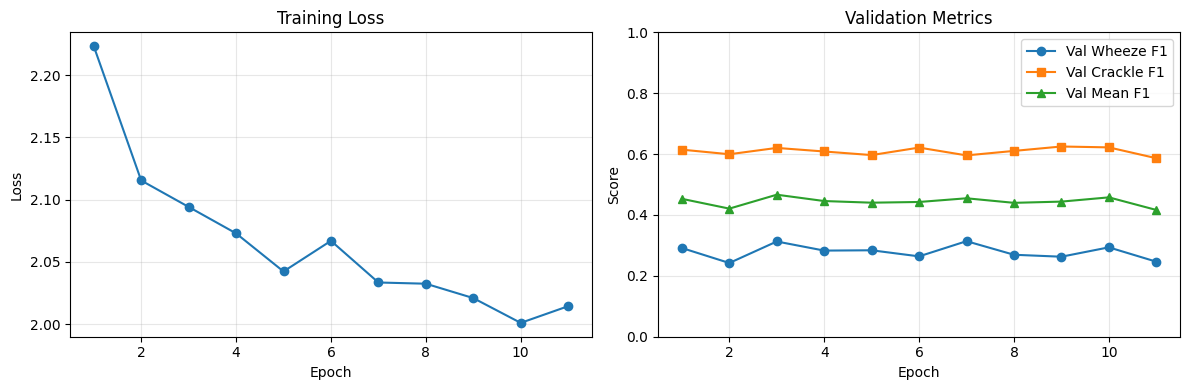


Step 5: Fit temperature scaling on validation logits
Wheeze temperature=0.5043 | val NLL before=0.60221, after=0.57868
Crackle temperature=2.9772 | val NLL before=0.70456, after=0.68909

Step 6: Re-tune thresholds on calibrated validation probabilities
Selected thresholds (calibrated): wheeze=0.29, crackle=0.44

Step 7: Final calibrated evaluation on test

=== FINAL TEST (CALIBRATED) ===
Frame Wheeze: {'tp': 1615, 'fp': 3080, 'tn': 1347, 'fn': 138, 'precision': 0.34398296059630584, 'recall': 0.9212778094689553, 'specificity': 0.30426925683300104, 'f1': 0.5009305206957451, 'balanced_accuracy': 0.6127735331509782, 'roc_auc': 0.6277403569420701, 'pr_auc': 0.3386432634067363}
Frame Crackle: {'tp': 2317, 'fp': 2736, 'tn': 817, 'fn': 310, 'precision': 0.4585394814960501, 'recall': 0.8819946707267293, 'specificity': 0.2299465240641064, 'f1': 0.6033854162164013, 'balanced_accuracy': 0.5559705973954179, 'roc_auc': 0.6716405261732956, 'pr_auc': 0.6168483696910301}
Chunk Wheeze: {'tp': 201, 'fp'

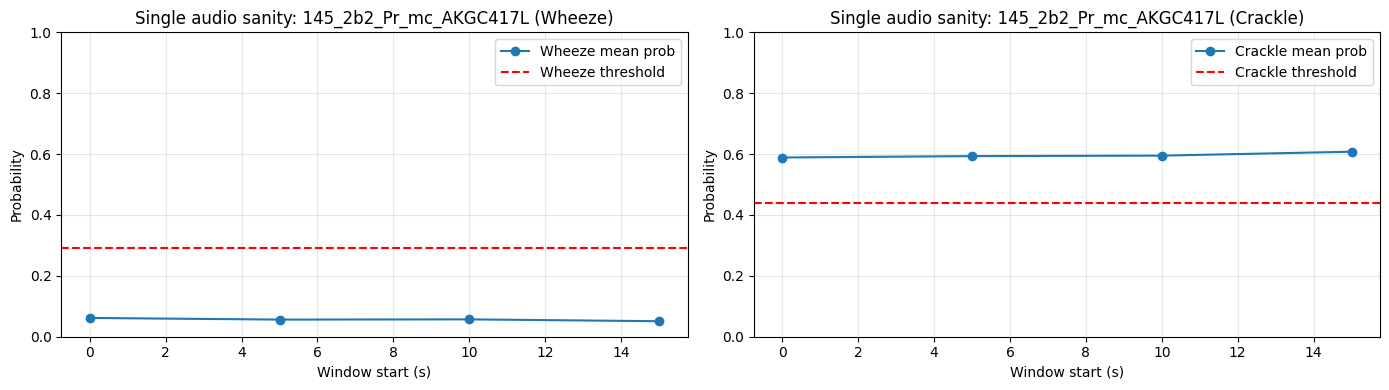

Saved: single_audio_sanity_summary.csv
Saved: single_audio_sanity_details.csv


In [23]:
# Optional launcher cell for retraining from scratch + temperature scaling
TRAINING_SPEED_PROFILE = "full"  # "quick" or "full"
RUN_GRAPHSAGE_SCRATCH_TS_NOW = True 

SPEED_PROFILES = {
    "quick": {
        "max_patients": 32,
        "epochs": 8,
        "batch_size": 12,
        "hidden_dim": 128,
        "num_layers": 2,
        "dropout": 0.35,
        "lr": 2e-4,
        "weight_decay": 1e-4,
        "temporal_hops": 2,
        "wheeze_loss_weight": 1.25,
        "crackle_loss_weight": 1.0,
        "pre_cache": False,
    },
    "full": {
        "max_patients": None,
        "epochs": 35,
        "batch_size": 8,
        "hidden_dim": 256,
        "num_layers": 3,
        "dropout": 0.5,
        "lr": 1e-4,
        "weight_decay": 2e-4,
        "temporal_hops": 2,
        "wheeze_loss_weight": 1.25,
        "crackle_loss_weight": 1.0,
        "pre_cache": False,
    },
}

# Post-training single-audio sanity tests (before multi-patient evaluation)
RUN_SINGLE_AUDIO_SANITY_TESTS = True
SINGLE_AUDIO_SANITY_FILES = 2
SINGLE_AUDIO_MIN_POS_FRAMES = 2
SINGLE_AUDIO_RESULTS_CSV = "single_audio_sanity_summary.csv"
SINGLE_AUDIO_DETAILS_CSV = "single_audio_sanity_details.csv"

print("=== Core Strategy Markers ===")
print("1) Train once for wheeze/crackle.")
print("2) Serve simultaneously on multiple separated streams.")
print("3) Optionally fine-tune for separator artifacts.")

required_symbols = [
    "run_graphsage_from_scratch_with_temperature_scaling",
    "Wav2Vec2FeatureCache",
    "build_similarity_edges",
    "sigmoid_np",
    "binary_stats",
]
missing_symbols = [s for s in required_symbols if s not in globals()]
if missing_symbols:
    raise RuntimeError(
        "Cell 4 must be run first. Missing symbols: " + ", ".join(missing_symbols)
    )


if TRAINING_SPEED_PROFILE not in SPEED_PROFILES:
    raise ValueError(
        "Invalid TRAINING_SPEED_PROFILE='{}'. Choose from {}".format(
            TRAINING_SPEED_PROFILE,
            sorted(SPEED_PROFILES.keys()),
        )
    )


profile_cfg = SPEED_PROFILES[TRAINING_SPEED_PROFILE]


def _subset_meta_by_patient(meta_df, max_patients=None, seed=42):
    if max_patients is None:
        return meta_df.reset_index(drop=True)

    unique_patients = np.array(sorted(meta_df["patient_id"].astype(str).unique()))
    if len(unique_patients) == 0:
        return meta_df.reset_index(drop=True)

    n = min(int(max_patients), len(unique_patients))
    rng = np.random.default_rng(seed)
    keep_patients = set(rng.choice(unique_patients, size=n, replace=False).tolist())

    return meta_df[
        meta_df["patient_id"].astype(str).isin(keep_patients)
    ].reset_index(drop=True)


meta_df_for_run = _subset_meta_by_patient(
    meta_df,
    max_patients=profile_cfg["max_patients"],
    seed=42,
)

print("\n=== Training Speed Profile ===")
print("Profile:", TRAINING_SPEED_PROFILE)
print("Files used:", len(meta_df_for_run), "of", len(meta_df))
print(
    "Patients used:",
    meta_df_for_run["patient_id"].astype(str).nunique(),
    "of",
    meta_df["patient_id"].astype(str).nunique(),
)
if TRAINING_SPEED_PROFILE == "quick":
    print("Quick profile is for fast sanity checks. Switch to full for final training.")
print("Temporal graph hops:", profile_cfg["temporal_hops"])
print("Task loss weights (wheeze, crackle):", profile_cfg["wheeze_loss_weight"], profile_cfg["crackle_loss_weight"])


def _patient_split(meta_df, seed=42):
    patients = meta_df["patient_id"].astype(str).unique()
    train_p, temp_p = train_test_split(patients, test_size=0.30, random_state=seed)
    val_p, test_p = train_test_split(temp_p, test_size=0.50, random_state=seed)

    train_df = meta_df[meta_df["patient_id"].astype(str).isin(train_p)].reset_index(drop=True)
    val_df = meta_df[meta_df["patient_id"].astype(str).isin(val_p)].reset_index(drop=True)
    test_df = meta_df[meta_df["patient_id"].astype(str).isin(test_p)].reset_index(drop=True)
    return train_df, val_df, test_df


def _window_truth_labels(ann_df, start_sec, end_sec):
    overlaps = ann_df[(ann_df["start"] < end_sec) & (ann_df["end"] > start_sec)]
    if len(overlaps) == 0:
        return 0, 0
    wheeze_true = int((overlaps["wheeze"] == 1).any())
    crackle_true = int((overlaps["crackle"] == 1).any())
    return wheeze_true, crackle_true


@torch.no_grad()
def _predict_chunk_frame_probs(model, x_np, wheeze_temperature, crackle_temperature, device, temporal_hops=2):
    edge_index = build_similarity_edges(x_np, k=4, temporal_hops=int(temporal_hops))
    graph = Data(
        x=torch.tensor(x_np, dtype=torch.float32),
        edge_index=edge_index,
    ).to(device)

    w_logits, c_logits = model(graph)
    w_logits_np = w_logits.detach().cpu().numpy().astype(np.float32)
    c_logits_np = c_logits.detach().cpu().numpy().astype(np.float32)

    w_prob = sigmoid_np(w_logits_np / max(float(wheeze_temperature), 1e-6))
    c_prob = sigmoid_np(c_logits_np / max(float(crackle_temperature), 1e-6))
    return w_prob, c_prob


def run_single_audio_sanity_tests(
    model,
    test_df,
    wheeze_threshold,
    crackle_threshold,
    wheeze_temperature,
    crackle_temperature,
    chunk_seconds=5.0,
    frame_seconds=0.5,
    temporal_hops=2,
    min_positive_frames=2,
    n_files=3,
    cache_dir="./cache/wav2vec2_embeddings",
    seed=42,
):
    if len(test_df) == 0:
        print("No test files available for single-audio sanity tests.")
        return pd.DataFrame(), pd.DataFrame()

    feature_cache = Wav2Vec2FeatureCache(
        cache_dir=cache_dir,
        sr=16000,
        frame_seconds=frame_seconds,
        device=WAV2VEC_DEVICE,
    )

    sample_df = test_df.sample(
        n=min(int(n_files), len(test_df)),
        random_state=seed,
    ).reset_index(drop=True)

    summary_rows = []
    detail_rows = []

    model.eval()

    for _, row in sample_df.iterrows():
        wav_path = row["wav_path"]
        ann_path = row["ann_path"]
        file_id = row.get("file_id", os.path.splitext(os.path.basename(wav_path))[0])

        ann_df = pd.read_csv(
            ann_path,
            sep="\t",
            header=None,
            names=["start", "end", "crackle", "wheeze"],
        )

        cache_data = feature_cache.compute_and_cache_file(wav_path)
        duration_sec = float(cache_data["audio_duration"])
        n_windows = max(1, int(np.ceil(duration_sec / float(chunk_seconds))))
        starts = np.arange(n_windows, dtype=np.float32) * float(chunk_seconds)

        y_w_true, y_c_true = [], []
        y_w_pred, y_c_pred = [], []

        for ws in starts:
            ws = float(ws)
            we = float(min(duration_sec, ws + float(chunk_seconds)))

            x_np = feature_cache.get_chunk_embeddings(wav_path, ws, chunk_seconds=chunk_seconds)
            w_prob, c_prob = _predict_chunk_frame_probs(
                model,
                x_np,
                wheeze_temperature=wheeze_temperature,
                crackle_temperature=crackle_temperature,
                device=TRAIN_DEVICE,
                temporal_hops=int(temporal_hops),
            )

            w_pos = int((w_prob >= float(wheeze_threshold)).sum())
            c_pos = int((c_prob >= float(crackle_threshold)).sum())

            w_pred = int(w_pos >= int(min_positive_frames))
            c_pred = int(c_pos >= int(min_positive_frames))

            w_true, c_true = _window_truth_labels(ann_df, ws, we)

            y_w_true.append(w_true)
            y_c_true.append(c_true)
            y_w_pred.append(w_pred)
            y_c_pred.append(c_pred)

            detail_rows.append({
                "file_id": file_id,
                "start_sec": ws,
                "end_sec": we,
                "wheeze_prob_mean": float(np.mean(w_prob)) if len(w_prob) else 0.0,
                "wheeze_prob_max": float(np.max(w_prob)) if len(w_prob) else 0.0,
                "crackle_prob_mean": float(np.mean(c_prob)) if len(c_prob) else 0.0,
                "crackle_prob_max": float(np.max(c_prob)) if len(c_prob) else 0.0,
                "wheeze_pos_frames": w_pos,
                "crackle_pos_frames": c_pos,
                "wheeze_pred_window": w_pred,
                "crackle_pred_window": c_pred,
                "wheeze_true_window": int(w_true),
                "crackle_true_window": int(c_true),
            })

        w_metrics = binary_stats(np.asarray(y_w_true), np.asarray(y_w_pred), threshold=0.5)
        c_metrics = binary_stats(np.asarray(y_c_true), np.asarray(y_c_pred), threshold=0.5)

        summary_rows.append({
            "file_id": file_id,
            "duration_sec": float(duration_sec),
            "windows": int(n_windows),
            "wheeze_f1": float(w_metrics["f1"]),
            "wheeze_precision": float(w_metrics["precision"]),
            "wheeze_recall": float(w_metrics["recall"]),
            "crackle_f1": float(c_metrics["f1"]),
            "crackle_precision": float(c_metrics["precision"]),
            "crackle_recall": float(c_metrics["recall"]),
        })

        print(
            f"[{file_id}] windows={n_windows} | "
            f"wheeze_f1={w_metrics['f1']:.4f} | crackle_f1={c_metrics['f1']:.4f}"
        )

    summary_df = pd.DataFrame(summary_rows)
    details_df = pd.DataFrame(detail_rows)

    if len(summary_df) > 0:
        print("\n=== Single-Audio Sanity Summary ===")
        print(summary_df.to_string(index=False))
        print("\nAverage across sampled files:")
        print(f"  Wheeze F1 : {summary_df['wheeze_f1'].mean():.4f}")
        print(f"  Crackle F1: {summary_df['crackle_f1'].mean():.4f}")

    if HAS_MATPLOTLIB and len(details_df) > 0:
        first_file = details_df["file_id"].iloc[0]
        first_df = details_df[details_df["file_id"] == first_file].copy()

        fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)

        axes[0].plot(first_df["start_sec"], first_df["wheeze_prob_mean"], marker="o", label="Wheeze mean prob")
        axes[0].axhline(float(wheeze_threshold), linestyle="--", color="r", label="Wheeze threshold")
        axes[0].set_title(f"Single audio sanity: {first_file} (Wheeze)")
        axes[0].set_xlabel("Window start (s)")
        axes[0].set_ylabel("Probability")
        axes[0].set_ylim(0, 1)
        axes[0].grid(alpha=0.3)
        axes[0].legend()

        axes[1].plot(first_df["start_sec"], first_df["crackle_prob_mean"], marker="o", label="Crackle mean prob")
        axes[1].axhline(float(crackle_threshold), linestyle="--", color="r", label="Crackle threshold")
        axes[1].set_title(f"Single audio sanity: {first_file} (Crackle)")
        axes[1].set_xlabel("Window start (s)")
        axes[1].set_ylabel("Probability")
        axes[1].set_ylim(0, 1)
        axes[1].grid(alpha=0.3)
        axes[1].legend()

        plt.tight_layout()
        plt.show()
    else:
        print("Skipping single-audio probability plot (matplotlib unavailable or no details).")

    return summary_df, details_df


if RUN_GRAPHSAGE_SCRATCH_TS_NOW:
    scratch_ts_results = run_graphsage_from_scratch_with_temperature_scaling(
        meta_df_for_run,
        seed=42,
        cache_dir="./cache/wav2vec2_embeddings",
        chunk_seconds=5.0,
        frame_seconds=0.5,
        batch_size=profile_cfg["batch_size"],
        hidden_dim=profile_cfg["hidden_dim"],
        num_layers=profile_cfg["num_layers"],
        dropout=profile_cfg["dropout"],
        epochs=profile_cfg["epochs"],
        lr=profile_cfg["lr"],
        weight_decay=profile_cfg["weight_decay"],
        temporal_hops=profile_cfg["temporal_hops"],
        wheeze_loss_weight=profile_cfg["wheeze_loss_weight"],
        crackle_loss_weight=profile_cfg["crackle_loss_weight"],
        pre_cache=profile_cfg["pre_cache"],
    )

    print("\nScratch GraphSAGE training with temperature scaling finished.")

    if RUN_SINGLE_AUDIO_SANITY_TESTS:
        _, _, test_df_eval = _patient_split(meta_df_for_run, seed=42)

        single_audio_summary_df, single_audio_details_df = run_single_audio_sanity_tests(
            model=scratch_ts_results["model"],
            test_df=test_df_eval,
            wheeze_threshold=float(scratch_ts_results["thresholds"]["wheeze"]),
            crackle_threshold=float(scratch_ts_results["thresholds"]["crackle"]),
            wheeze_temperature=float(scratch_ts_results["temperature"]["wheeze"]),
            crackle_temperature=float(scratch_ts_results["temperature"]["crackle"]),
            chunk_seconds=5.0,
            frame_seconds=0.5,
            temporal_hops=int(profile_cfg["temporal_hops"]),
            min_positive_frames=SINGLE_AUDIO_MIN_POS_FRAMES,
            n_files=SINGLE_AUDIO_SANITY_FILES,
            cache_dir="./cache/wav2vec2_embeddings",
            seed=42,
        )

        if len(single_audio_summary_df) > 0:
            single_audio_summary_df.to_csv(SINGLE_AUDIO_RESULTS_CSV, index=False)
            single_audio_details_df.to_csv(SINGLE_AUDIO_DETAILS_CSV, index=False)
            print(f"Saved: {SINGLE_AUDIO_RESULTS_CSV}")
            print(f"Saved: {SINGLE_AUDIO_DETAILS_CSV}")

        scratch_ts_results["single_audio_summary_df"] = single_audio_summary_df
        scratch_ts_results["single_audio_details_df"] = single_audio_details_df
else:
    print("Launcher is OFF.")
    print("Set RUN_GRAPHSAGE_SCRATCH_TS_NOW=True to start retraining from this cell.")
    print("Current profile:", TRAINING_SPEED_PROFILE)
    print("Single-audio sanity tests will run automatically after training if enabled.")

In [ ]:
# Cell 7: Threshold sweep for ward deployment (no retraining)
import os
import json
import numpy as np
import pandas as pd
import torch
from torch_geometric.loader import DataLoader

RUN_WARD_THRESHOLD_SWEEP = True

SWEEP_MODEL_CANDIDATES = [
    os.path.join("output files", "saved models", "best_respiratory_graphsage_temp_scaled.pth"),
    "best_respiratory_graphsage_temp_scaled.pth",
    "respiratory_graphsage_temp_scaled.pth",
]
SWEEP_META_JSON = "graphsage_temp_scaling_meta.json"
SWEEP_CACHE_DIR = "./cache/wav2vec2_embeddings"
SWEEP_OUTPUT_DIR = os.path.join("output files", "sample_runs", "threshold_sweep_eval")
SWEEP_FORCE_REBUILD_LOGITS = False

SWEEP_SEED = 42
SWEEP_BATCH_SIZE = 1
SWEEP_T_MIN = 0.05
SWEEP_T_MAX = 0.95
SWEEP_T_STEP = 0.01
SWEEP_MIN_POSITIVE_FRAMES = 2

# Ward deployment target: reduce false alarms by favoring precision and specificity.
SWEEP_TARGET_PRECISION = 0.60
SWEEP_TARGET_SPECIFICITY = 0.60



def _find_first_existing(paths):
    for p in paths:
        if os.path.exists(p):
            return p
    return None



def _patient_split_local(meta_df, seed=42):
    from sklearn.model_selection import train_test_split

    patients = meta_df["patient_id"].astype(str).unique()
    train_p, temp_p = train_test_split(patients, test_size=0.30, random_state=int(seed))
    val_p, test_p = train_test_split(temp_p, test_size=0.50, random_state=int(seed))

    train_df = meta_df[meta_df["patient_id"].astype(str).isin(train_p)].reset_index(drop=True)
    val_df = meta_df[meta_df["patient_id"].astype(str).isin(val_p)].reset_index(drop=True)
    test_df = meta_df[meta_df["patient_id"].astype(str).isin(test_p)].reset_index(drop=True)
    return train_df, val_df, test_df



def _load_checkpoint_artifact_for_sweep(model_path):
    payload = torch.load(model_path, map_location="cpu")

    if isinstance(payload, dict) and "model_state_dict" in payload:
        state_dict = payload["model_state_dict"]
        config = payload.get("config", {})
        temperature = payload.get("temperature", {})
        thresholds = payload.get("thresholds", {})
    elif isinstance(payload, dict):
        state_dict = payload
        config = {}
        temperature = {}
        thresholds = {}
    else:
        raise ValueError("Unsupported checkpoint format for threshold sweep.")

    return state_dict, config, temperature, thresholds



def _load_meta_json(path):
    if not os.path.isfile(path):
        return {}
    try:
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    except Exception:
        return {}



def _threshold_sweep_df(y_true, y_prob, t_min=0.05, t_max=0.95, t_step=0.01):
    rows = []
    for t in np.arange(float(t_min), float(t_max) + 1e-9, float(t_step)):
        m = binary_stats(y_true, y_prob, threshold=float(t))
        rows.append(
            {
                "threshold": float(t),
                "tp": int(m["tp"]),
                "fp": int(m["fp"]),
                "tn": int(m["tn"]),
                "fn": int(m["fn"]),
                "precision": float(m["precision"]),
                "recall": float(m["recall"]),
                "specificity": float(m["specificity"]),
                "f1": float(m["f1"]),
                "balanced_accuracy": float(m["balanced_accuracy"]),
                "roc_auc": m["roc_auc"],
                "pr_auc": m["pr_auc"],
                "positive_rate": float(np.mean(np.asarray(y_prob) >= float(t))),
            }
        )
    return pd.DataFrame(rows)



def _chunk_threshold_sweep_df(prob, true, chunk_ids, min_positive_frames=2, t_min=0.05, t_max=0.95, t_step=0.01):
    rows = []
    for t in np.arange(float(t_min), float(t_max) + 1e-9, float(t_step)):
        m = chunk_level_eval(
            prob,
            true,
            chunk_ids,
            threshold=float(t),
            min_positive_frames=int(min_positive_frames),
        )
        rows.append(
            {
                "threshold": float(t),
                "tp": int(m["tp"]),
                "fp": int(m["fp"]),
                "tn": int(m["tn"]),
                "fn": int(m["fn"]),
                "precision": float(m["precision"]),
                "recall": float(m["recall"]),
                "specificity": float(m["specificity"]),
                "f1": float(m["f1"]),
                "balanced_accuracy": float(m["balanced_accuracy"]),
                "roc_auc": m["roc_auc"],
                "pr_auc": m["pr_auc"],
            }
        )
    return pd.DataFrame(rows)



def _pick_operating_point(sweep_df, min_precision=0.60, min_specificity=0.60):
    eligible = sweep_df[
        (sweep_df["precision"] >= float(min_precision))
        & (sweep_df["specificity"] >= float(min_specificity))
    ]

    if len(eligible) > 0:
        chosen = eligible.sort_values(
            ["recall", "f1", "balanced_accuracy"],
            ascending=[False, False, False],
        ).iloc[0]
        return chosen, "meets_target", int(len(eligible))

    chosen = sweep_df.sort_values(
        ["precision", "specificity", "f1", "recall"],
        ascending=[False, False, False, False],
    ).iloc[0]
    return chosen, "fallback_best_prec_spec", 0



def _prepare_or_load_test_logits(
    model_path,
    state_dict,
    config,
    cache_dir,
    output_dir,
    force_rebuild=False,
    seed=42,
    batch_size=1,
):
    os.makedirs(output_dir, exist_ok=True)
    logits_npz = os.path.join(output_dir, "test_logits_cache.npz")
    info_json = os.path.join(output_dir, "test_logits_cache_info.json")

    if os.path.isfile(logits_npz) and not bool(force_rebuild):
        data = np.load(logits_npz)
        info = _load_meta_json(info_json)
        return {
            "w_logits": data["w_logits"].astype(np.float32),
            "c_logits": data["c_logits"].astype(np.float32),
            "w_true": data["w_true"].astype(np.float32),
            "c_true": data["c_true"].astype(np.float32),
            "chunk_ids": data["chunk_ids"].astype(np.int64),
            "info": info,
            "source": "cache",
            "cache_path": logits_npz,
        }

    required = [
        "RespiratoryGraphDataset",
        "RespiratoryGraphSAGE",
        "collect_logits_targets",
        "sigmoid_np",
        "binary_stats",
        "chunk_level_eval",
        "meta_df",
    ]
    missing = [k for k in required if k not in globals()]
    if len(missing) > 0:
        raise RuntimeError(
            "Run Cell 2 and Cell 4 first. Missing symbols: " + ", ".join(missing)
        )

    _, _, test_df = _patient_split_local(meta_df, seed=int(seed))

    chunk_seconds = float(config.get("chunk_seconds", 5.0))
    frame_seconds = float(config.get("frame_seconds", 0.5))
    hidden_dim = int(config.get("hidden_dim", 256))
    num_layers = int(config.get("num_layers", 3))
    dropout = float(config.get("dropout", 0.5))
    temporal_hops = int(config.get("temporal_hops", 2))

    test_dataset = RespiratoryGraphDataset(
        test_df,
        cache_dir=cache_dir,
        chunk_seconds=chunk_seconds,
        frame_seconds=frame_seconds,
        k_edges=4,
        crackle_focus_enabled=False,
        samples_per_file=6,
        temporal_hops=int(temporal_hops),
        pre_cache=False,
    )
    test_loader = DataLoader(test_dataset, batch_size=int(batch_size), shuffle=False)

    eval_device = TRAIN_DEVICE if "TRAIN_DEVICE" in globals() else torch.device("cpu")

    model = RespiratoryGraphSAGE(
        input_dim=768,
        hidden_dim=hidden_dim,
        num_layers=num_layers,
        dropout=dropout,
    ).to(eval_device)
    model.load_state_dict(state_dict, strict=True)
    model.eval()

    w_logits, c_logits, w_true, c_true, chunk_ids = collect_logits_targets(model, test_loader, eval_device)

    np.savez_compressed(
        logits_npz,
        w_logits=w_logits.astype(np.float32),
        c_logits=c_logits.astype(np.float32),
        w_true=w_true.astype(np.float32),
        c_true=c_true.astype(np.float32),
        chunk_ids=chunk_ids.astype(np.int64),
    )

    info = {
        "model_path": str(model_path),
        "n_test_files": int(len(test_df)),
        "n_test_patients": int(test_df["patient_id"].astype(str).nunique()) if len(test_df) else 0,
        "n_nodes": int(len(w_true)),
        "chunk_seconds": float(chunk_seconds),
        "frame_seconds": float(frame_seconds),
        "temporal_hops": int(temporal_hops),
    }
    with open(info_json, "w", encoding="utf-8") as f:
        json.dump(info, f, indent=2)

    return {
        "w_logits": w_logits.astype(np.float32),
        "c_logits": c_logits.astype(np.float32),
        "w_true": w_true.astype(np.float32),
        "c_true": c_true.astype(np.float32),
        "chunk_ids": chunk_ids.astype(np.int64),
        "info": info,
        "source": "recomputed",
        "cache_path": logits_npz,
    }



if RUN_WARD_THRESHOLD_SWEEP:
    model_path = _find_first_existing(SWEEP_MODEL_CANDIDATES)
    if model_path is None:
        raise FileNotFoundError(
            "No checkpoint found. Checked: " + ", ".join(SWEEP_MODEL_CANDIDATES)
        )

    state_dict, ckpt_config, ckpt_temp, ckpt_thresholds = _load_checkpoint_artifact_for_sweep(model_path)
    meta_payload = _load_meta_json(SWEEP_META_JSON)

    meta_temp = meta_payload.get("temperature", {}) if isinstance(meta_payload, dict) else {}
    meta_thr = meta_payload.get("thresholds", {}) if isinstance(meta_payload, dict) else {}

    wheeze_temp = float(ckpt_temp.get("wheeze", meta_temp.get("wheeze", 1.0)))
    crackle_temp = float(ckpt_temp.get("crackle", meta_temp.get("crackle", 1.0)))

    base_w_t = float(ckpt_thresholds.get("wheeze", meta_thr.get("wheeze", 0.50)))
    base_c_t = float(ckpt_thresholds.get("crackle", meta_thr.get("crackle", 0.50)))

    logits_bundle = _prepare_or_load_test_logits(
        model_path=model_path,
        state_dict=state_dict,
        config=ckpt_config,
        cache_dir=SWEEP_CACHE_DIR,
        output_dir=SWEEP_OUTPUT_DIR,
        force_rebuild=SWEEP_FORCE_REBUILD_LOGITS,
        seed=SWEEP_SEED,
        batch_size=SWEEP_BATCH_SIZE,
    )

    w_logits = logits_bundle["w_logits"]
    c_logits = logits_bundle["c_logits"]
    w_true = logits_bundle["w_true"]
    c_true = logits_bundle["c_true"]
    chunk_ids = logits_bundle["chunk_ids"]

    w_prob = sigmoid_np(w_logits / max(float(wheeze_temp), 1e-6))
    c_prob = sigmoid_np(c_logits / max(float(crackle_temp), 1e-6))

    frame_w_df = _threshold_sweep_df(w_true, w_prob, SWEEP_T_MIN, SWEEP_T_MAX, SWEEP_T_STEP)
    frame_w_df.insert(0, "level", "frame")
    frame_w_df.insert(1, "task", "wheeze")

    frame_c_df = _threshold_sweep_df(c_true, c_prob, SWEEP_T_MIN, SWEEP_T_MAX, SWEEP_T_STEP)
    frame_c_df.insert(0, "level", "frame")
    frame_c_df.insert(1, "task", "crackle")

    chunk_w_df = _chunk_threshold_sweep_df(
        w_prob,
        w_true,
        chunk_ids,
        min_positive_frames=SWEEP_MIN_POSITIVE_FRAMES,
        t_min=SWEEP_T_MIN,
        t_max=SWEEP_T_MAX,
        t_step=SWEEP_T_STEP,
    )
    chunk_w_df.insert(0, "level", "chunk")
    chunk_w_df.insert(1, "task", "wheeze")

    chunk_c_df = _chunk_threshold_sweep_df(
        c_prob,
        c_true,
        chunk_ids,
        min_positive_frames=SWEEP_MIN_POSITIVE_FRAMES,
        t_min=SWEEP_T_MIN,
        t_max=SWEEP_T_MAX,
        t_step=SWEEP_T_STEP,
    )
    chunk_c_df.insert(0, "level", "chunk")
    chunk_c_df.insert(1, "task", "crackle")

    ward_threshold_sweep_df = pd.concat(
        [frame_w_df, frame_c_df, chunk_w_df, chunk_c_df],
        ignore_index=True,
    )

    op_rows = []
    for level_name, task_name, df_now, base_t in [
        ("frame", "wheeze", frame_w_df, base_w_t),
        ("frame", "crackle", frame_c_df, base_c_t),
        ("chunk", "wheeze", chunk_w_df, base_w_t),
        ("chunk", "crackle", chunk_c_df, base_c_t),
    ]:
        pick, mode, eligible_count = _pick_operating_point(
            df_now,
            min_precision=SWEEP_TARGET_PRECISION,
            min_specificity=SWEEP_TARGET_SPECIFICITY,
        )

        base_row = df_now.iloc[(np.abs(df_now["threshold"].values - float(base_t))).argmin()]

        op_rows.append(
            {
                "level": level_name,
                "task": task_name,
                "selection_mode": mode,
                "eligible_count": int(eligible_count),
                "target_precision": float(SWEEP_TARGET_PRECISION),
                "target_specificity": float(SWEEP_TARGET_SPECIFICITY),
                "baseline_threshold": float(base_row["threshold"]),
                "baseline_precision": float(base_row["precision"]),
                "baseline_specificity": float(base_row["specificity"]),
                "baseline_recall": float(base_row["recall"]),
                "baseline_f1": float(base_row["f1"]),
                "recommended_threshold": float(pick["threshold"]),
                "recommended_precision": float(pick["precision"]),
                "recommended_specificity": float(pick["specificity"]),
                "recommended_recall": float(pick["recall"]),
                "recommended_f1": float(pick["f1"]),
            }
        )

    ward_threshold_operating_points_df = pd.DataFrame(op_rows)

    os.makedirs(SWEEP_OUTPUT_DIR, exist_ok=True)
    sweep_csv = os.path.join(SWEEP_OUTPUT_DIR, "ward_threshold_sweep_table.csv")
    operating_csv = os.path.join(SWEEP_OUTPUT_DIR, "ward_threshold_operating_points.csv")

    ward_threshold_sweep_df.to_csv(sweep_csv, index=False)
    ward_threshold_operating_points_df.to_csv(operating_csv, index=False)

    print("=== Ward Threshold Sweep (No Retraining) ===")
    print("Checkpoint:", model_path)
    print("Logits source:", logits_bundle["source"])
    print("Logits cache:", logits_bundle["cache_path"])
    print("Wheeze temperature:", round(wheeze_temp, 4), "| Crackle temperature:", round(crackle_temp, 4))
    print("Base thresholds -> wheeze:", round(base_w_t, 3), ", crackle:", round(base_c_t, 3))
    print("Target precision/specificity ->", SWEEP_TARGET_PRECISION, "/", SWEEP_TARGET_SPECIFICITY)

    print("\nRecommended operating points:")
    print(ward_threshold_operating_points_df.to_string(index=False))

    show_cols = [
        "level",
        "task",
        "threshold",
        "precision",
        "specificity",
        "recall",
        "f1",
        "balanced_accuracy",
        "tp",
        "fp",
        "tn",
        "fn",
    ]

    print("\nTop precision/specificity candidates (frame wheeze):")
    print(frame_w_df.sort_values(["precision", "specificity", "f1"], ascending=False)[show_cols].head(8).to_string(index=False))

    print("\nTop precision/specificity candidates (frame crackle):")
    print(frame_c_df.sort_values(["precision", "specificity", "f1"], ascending=False)[show_cols].head(8).to_string(index=False))

    print("\nSaved:", sweep_csv)
    print("Saved:", operating_csv)
else:
    print("RUN_WARD_THRESHOLD_SWEEP=False -> skipped.")